In [1]:
import torch
from src.model import TransformDecoder, ImageTransformPredictor
from src.dataset import ImageTransformer, TransformTokenizer
from src.dataset import DomainNetDataset, get_domainnet_dataloaders
from PIL import Image
from omegaconf import OmegaConf
from torchvision import transforms

%load_ext autoreload
%autoreload 2

In [2]:
# !pip install efficientnet_pytorch
# !pip install --upgrade torchvision

In [3]:
# /home/jovyan/.mlspace/envs/genimages

### Testing Model

In [2]:
config = OmegaConf.load('configs/train_config_011.yaml')

# preprocess = transforms.Compose([
#             transforms.Resize((224, 224)),
#             transforms.ToTensor(),
#             transforms.Normalize([0.485, 0.456, 0.406], [0.229, 0.224, 0.225]),
#         ])

preprocess = transforms.Compose([
            transforms.Resize((300, 300)),
            transforms.ToTensor(),
            transforms.Normalize([0.485, 0.456, 0.406], [0.229, 0.224, 0.225]),
        ])

In [3]:
model = ImageTransformPredictor(config.model)

Loaded pretrained weights for efficientnet-b3


In [4]:
# model.load_state_dict(torch.load('checkpoints/itp_011/model_weights.pth'))
# model.to('cpu')
# model.eval()
# print('ready')

In [5]:
# checkpoint_path = 'checkpoints/itp_vit/checkpoint_epoch_100.pth'
# checkpoint_path = 'checkpoints/itp_011/checkpoint_epoch_50.pth'
# checkpoint_path = 'checkpoints/itp_010/checkpoint_epoch_16.pth' # хороший у 010
# checkpoint_path = 'checkpoints/itp_009/checkpoint_epoch_20.pth'
checkpoint_path = 'checkpoints/itp_011_tune/checkpoint_epoch_4.pth'

checkpoint = torch.load(checkpoint_path, map_location='cpu', weights_only=False)
model.load_state_dict(checkpoint['model_state_dict'])
model.to('cpu')
model.eval()
print('ready')

ready


In [5]:
# torch.save(model.state_dict(), 'checkpoints/itp_vit/model_weights.pth')

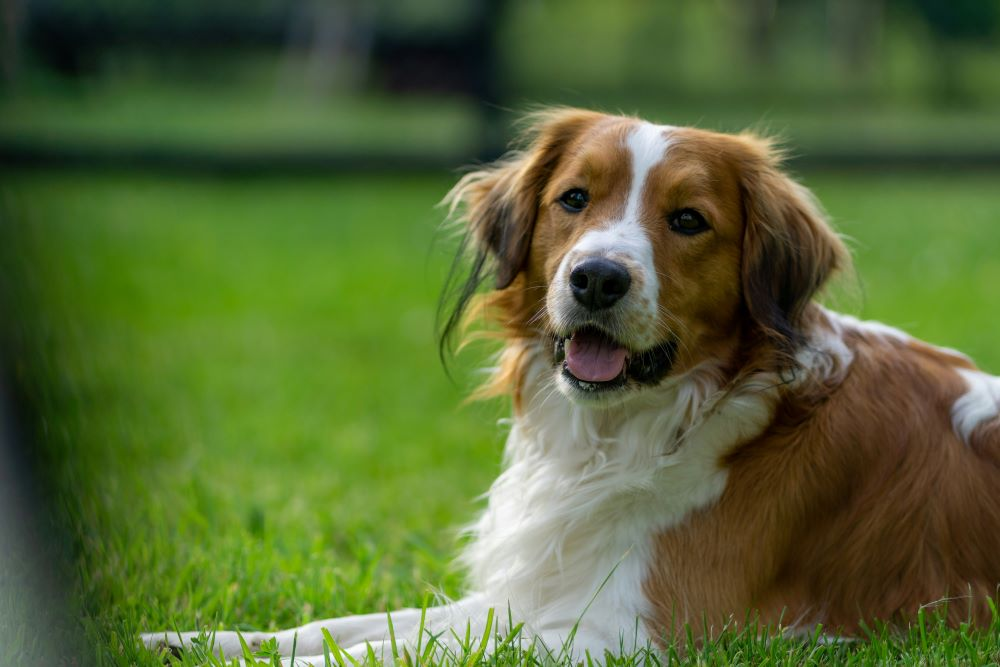

In [5]:
image_path_1 = 'assets/image.jpg'
image_path_2 = 'assets/dog.jpg'

image_1 = Image.open(image_path_1)
image_2 = Image.open(image_path_2)
image_1

['rotate_180', 'noise_adding', 'crop']


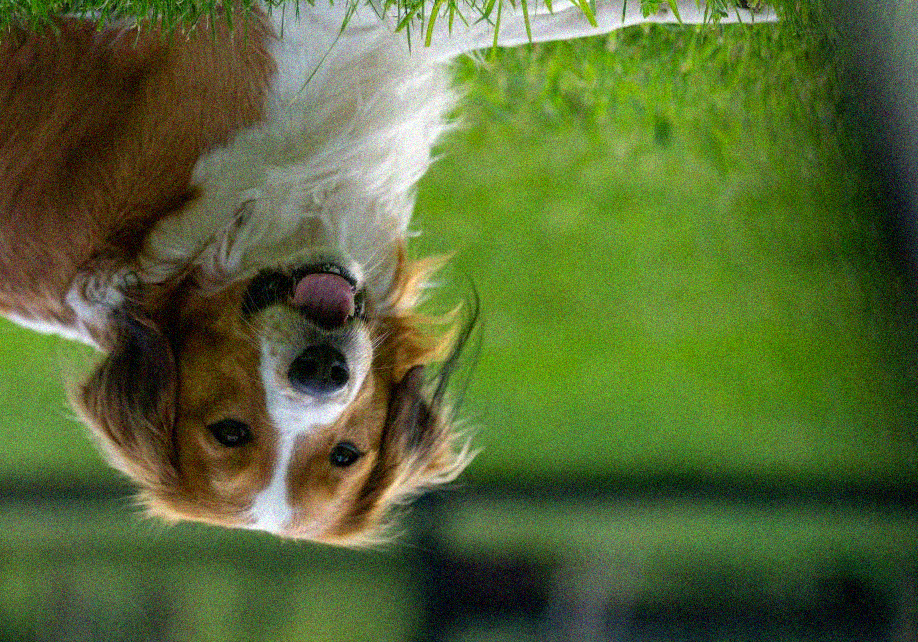

In [10]:
image_path_1 = 'assets/image.jpg'
image_path_2 = 'assets/dog.jpg'

image_1 = Image.open(image_path_1)
image_2 = Image.open(image_path_2)

it = ImageTransformer()
transformed_image_1, sequence_1 = it.transform(image_1, 0.3)
print(sequence_1)
transformed_image_1

In [13]:
image_tensor_1 = preprocess(image_1).unsqueeze(0)
image_tensor_2 = preprocess(image_2).unsqueeze(0)
transformed_image_tensor = preprocess(transformed_image_1).unsqueeze(0)

generated = model.generate(image_tensor_1, image_tensor_1, max_new_tokens=10, do_sample=False)
# generated = model.generate(image_tensor_1, transformed_image_tensor, max_new_tokens=10, do_sample=True, top_k=3)

tokenizer = TransformTokenizer()
tokens = tokenizer.decode(generated[0], skip_special_tokens=True)
print(f"Predicted: {tokens}")
print(f"Target: {sequence_1}")

Predicted: ['noop']
Target: ['rotate_180', 'noise_adding', 'crop']


In [49]:
image_1 = Image.open("/mnt/DATA2/dorin/imgs/texts_new/text_1.jpg")
image_2 = Image.open("/mnt/DATA2/dorin/imgs/texts_new/text_3.jpg")

image_tensor_1 = preprocess(image_1).unsqueeze(0)
image_tensor_2 = preprocess(image_2).unsqueeze(0)

generated = model.generate(image_tensor_1, image_tensor_2, max_new_tokens=10, do_sample=False)
# generated = model.generate(image_tensor_1, image_tensor_2, max_new_tokens=10, do_sample=True, top_k=3)

tokenizer = TransformTokenizer()
tokens = tokenizer.decode(generated[0], skip_special_tokens=True)
print(f"Predicted: {tokens}")

Predicted: []


### ViT Encoder

In [3]:
from src.model import ViTImageEncoder, ImagePairEncoderViT

In [7]:
config = OmegaConf.load('configs/train_config_vit.yaml')

model = ImagePairEncoderViT(config.model.encoder)
preprocess = model.preprocess

In [10]:
image_path = 'assets/image.jpg'

image = Image.open(image_path)
image_tensor = preprocess(image).unsqueeze(0)
model(image_tensor, image_tensor).shape

torch.Size([1, 395, 512])

In [21]:
import torch.nn as nn
from torchvision.models import vit_b_16, ViT_B_16_Weights

weights = ViT_B_16_Weights.IMAGENET1K_V1
vit = vit_b_16(weights=weights)
vit.heads = nn.Identity()

### Image Preprocess

In [3]:
from torchvision.models import vit_b_16, ViT_B_16_Weights
from torchvision import transforms
from PIL import Image

weights = ViT_B_16_Weights.IMAGENET1K_V1
preprocess_transform = weights.transforms()


image_path = 'assets/image.jpg'

image = Image.open(image_path)
image_tensor = preprocess_transform(image).shape

По сути у ViT тут:
```
transform = transforms.Compose([
    transforms.Resize(256, interpolation=InterpolationMode.BILINEAR),  # Изменение размера до 256x256
    transforms.CenterCrop(224),  # Центральный кроп до 224x224
    transforms.ToTensor(),  # Преобразование в тензор
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225]),  # Нормализация
])
```

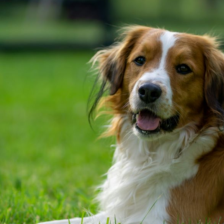

In [ ]:
from PIL import Image
from torchvision.transforms.functional import to_pil_image
import torch
from torchvision.models import ViT_B_16_Weights


weights = ViT_B_16_Weights.IMAGENET1K_V1
preprocess_transform = weights.transforms()

image_path = 'assets/image.jpg'
image = Image.open(image_path).convert("RGB")
image_tensor = preprocess_transform(image)

mean = torch.tensor([0.485, 0.456, 0.406]).view(-1, 1, 1)
std = torch.tensor([0.229, 0.224, 0.225]).view(-1, 1, 1)

denorm_tensor = image_tensor * std + mean
denorm_tensor = torch.clamp(denorm_tensor, 0, 1)

pil_image = to_pil_image(denorm_tensor)
pil_image

In [10]:
from torchvision.models import EfficientNet_B3_Weights

weights = EfficientNet_B3_Weights.IMAGENET1K_V1
preprocess = weights.transforms()

У EfficientNet-B3 аналогично оригинальные размеры 300.
```
transform = transforms.Compose([
    transforms.Resize(320, interpolation=InterpolationMode.BICUBIC),  # Изменение размера до 320x320 с бикубической интерполяцией
    transforms.CenterCrop(300),  # Центральный кроп до 300x300
    transforms.ToTensor(),  # Преобразование в тензор
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225]),  # Нормализация
])
```
- EfficientNet поддерживает произвольные размеры благодаря AdaptiveAvgPool2d.
- Это не "динамический препроцессинг" как в Qwen-VL, а гибкая CNN-архитектура.
- Но предобученные веса оптимальны только для native resolution.
- Для максимальной точности: ресайз до native size модели (лучше с паддингом, если не хотите кропа).

In [ ]:
from efficientnet_pytorch import EfficientNet

model_name = 'efficientnet-b3'
image_size = EfficientNet.get_image_size(model_name)
image_size

300

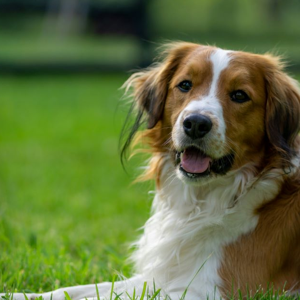

In [ ]:
from PIL import Image
from torchvision import transforms
from torchvision.transforms import InterpolationMode
import torch


transform = transforms.Compose([
    transforms.Resize(320, interpolation=InterpolationMode.BICUBIC), # меньшую сторону до 320
    transforms.CenterCrop(300),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225]),
])

image_path = 'assets/image.jpg'
image = Image.open(image_path).convert("RGB")
image_tensor = transform(image)

# Денормализация
mean = torch.tensor([0.485, 0.456, 0.406]).view(-1, 1, 1)
std = torch.tensor([0.229, 0.224, 0.225]).view(-1, 1, 1)

denorm_tensor = image_tensor * std + mean
denorm_tensor = torch.clamp(denorm_tensor, 0, 1)

# Преобразование в PIL
pil_image = to_pil_image(denorm_tensor)
pil_image

У нас же в EffNet:

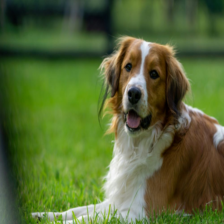

In [17]:
from PIL import Image
from torchvision import transforms
from torchvision.transforms import InterpolationMode
import torch


transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225]),
])

image_path = 'assets/image.jpg'
image = Image.open(image_path).convert("RGB")
image_tensor = transform(image)

mean = torch.tensor([0.485, 0.456, 0.406]).view(-1, 1, 1)
std = torch.tensor([0.229, 0.224, 0.225]).view(-1, 1, 1)

denorm_tensor = image_tensor * std + mean
denorm_tensor = torch.clamp(denorm_tensor, 0, 1)

pil_image = to_pil_image(denorm_tensor)
pil_image

### Negative Dataset

In [19]:
from src.dataset import NegativeImagePairDataset, get_negative_pair_dataloaders

In [20]:
it = ImageTransformer()
tokenizer = TransformTokenizer()

In [4]:
data = NegativeImagePairDataset(
        root_dir = "/mnt/DATA2/dorin/res.cv.science.dataset.generation/datasets",
        batch_names = ["dataset_0", "dataset_1", "dataset_5", "dataset_9"],
        transformer = it,
        tokenizer = tokenizer,
        split = "train",
        val_size = 0.1,
        random_seed = 42,
        max_seq_len = 15,
        augmentation_p = 0.5
)

In [5]:
len(data)

354411

In [15]:
img1_t, img2_t, img1_aug_t, img2_aug_t, seq1_tensor, seq2_tensor = next(iter(data))

In [16]:
img1_t.shape

torch.Size([3, 224, 224])

In [17]:
seq2_tensor

tensor([ 1,  7,  9, 12,  2,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0])

In [22]:
dataloaders = get_negative_pair_dataloaders(
        root_dir = "/mnt/DATA2/dorin/res.cv.science.dataset.generation/datasets",
        batch_names = ["dataset_0", "dataset_1", "dataset_5", "dataset_9"],
        transformer = it,
        tokenizer = tokenizer,
        batch_size = 32,
        num_workers = 4,
        val_size = 0.1)

In [25]:
for img1_t, img2_t, img1_aug_t, img2_aug_t, seq1_tensor, seq2_tensor in dataloaders["train"]:
    print(img1_t.shape)
    print(img1_aug_t.shape)
    print(seq1_tensor.shape)
    break

torch.Size([32, 3, 224, 224])
torch.Size([32, 3, 224, 224])
torch.Size([32, 15])
